This code uses the **pycom** Python package to fetch the co-evolutionary pairwise coupling obtained by Direct Coupling Analysis. For pycom's documentation see https://pycom.brunel.ac.uk/.

User should specify the UniProt ID of the protein for which they want to retreive the direct coupling maps.

The program saves the coupling matrices as '(UNIPROT_ID)_direct_coupling.csv' without headers and an index. In addition, the matrix is visualised using matplotlib.

In [1]:
!pip3 install git+https://github.com/scdantu/pycom

  Cloning https://github.com/scdantu/pycom to /tmp/pip-req-build-v356z2_i
  Running command git clone --filter=blob:none --quiet https://github.com/scdantu/pycom /tmp/pip-req-build-v356z2_i
  Resolved https://github.com/scdantu/pycom to commit 0674415815db9272d31b05fe15268a7a0875a27e
  Preparing metadata (setup.py) ... done
  Created wheel for pycom: filename=pycom-1.0.8-py3-none-any.whl size=28053 sha256=0a6e220f3925f86155123f476ffb85f849141c5e8e64485743fa1d28d817d48d
  Stored in directory: /tmp/pip-ephem-wheel-cache-5du44e5z/wheels/d1/28/33/3074f41a4e55ee98de6e5e52df03f429ceb6915aa1d403ce80
Successfully built pycom


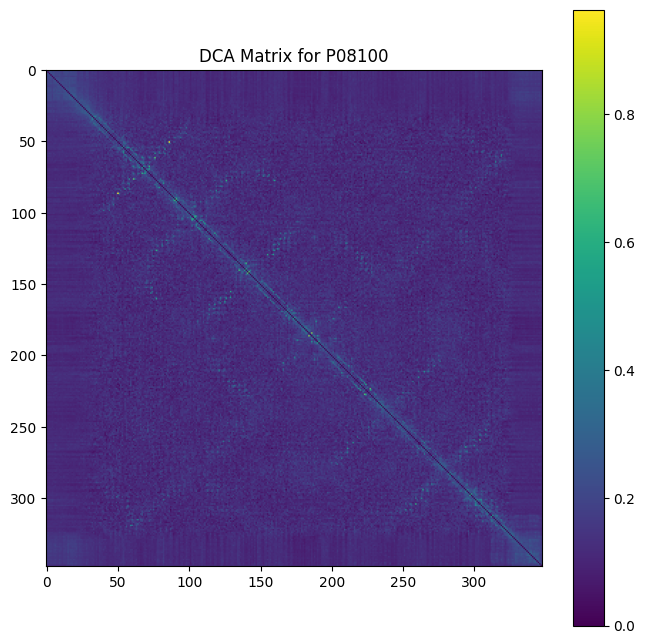

Matrix shape: (348, 348)


In [4]:
from pycom import PyCom, CoMAnalysis
import matplotlib.pyplot as plt
import numpy as np

UNIPROT_ID = 'P08100' #this is for Rhodopsin
pyc = PyCom(remote=True)

prots = pyc.find(
    uniprot_id=UNIPROT_ID,
    matrix=True,
    page=1
)

CoMAnalysis().add_contact_predictions(prots)

mat = prots.matrix[0]
np.savetxt(f'{UNIPROT_ID}_direct_coupling.csv', mat, delimiter=',')

plt.figure(figsize=(8,8))
plt.title(f'DCA Matrix for {prots.uniprot_id[0]}')
plt.imshow(mat)
plt.colorbar()
plt.show()

print(f"Matrix shape:{mat.shape}")
